In [19]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('/workspaces/Analisis-Matrimonios-y-Divorcios-2020---Proyecto-FCDIA-/ProeyctoFCDIA/EDV_2020.csv', sep=';')

def limpiar_sentinela(df, columnas, valor):
    df[columnas] = df[columnas].replace(valor, pd.NA)

# Diccionario: valor centinela -> columnas
sentinelas = {
    99: [
        'niv_inst2','hijos_2','dia_nac2','mes_nac2',
        'niv_inst1','hijos_1','dia_nac1','cau_div','mes_nac1'
    ],
    9:  ['mcap_bie','nac_1','nac_2','sabe_leer1','sabe_leer2'],
    999: ['edad_1','edad_2'],
    9999: ['anio_nac1','anio_nac2']
}

# Aplicar limpieza
for valor, columnas in sentinelas.items():
    limpiar_sentinela(df, columnas, valor)

# Limpieza de columnas de fecha
columnas_fechas = [
    'fecha_insc','fecha_nac2','fecha_nac1','fecha_div','fecha_mat'
]
df[columnas_fechas] = df[columnas_fechas].replace(' ', pd.NA)

df = df.dropna().reset_index(drop=True)

In [20]:
df.columns

Index(['prov_insc', 'cant_insc', 'parr_insc', 'anio_insc', 'mes_insc',
       'dia_insc', 'fecha_insc', 'anio_div', 'mes_div', 'dia_div', 'fecha_div',
       'anio_mat', 'mes_mat', 'dia_mat', 'fecha_mat', 'mcap_bie', 'dur_mat',
       'cau_div', 'nac_1', 'cod_pais1', 'sexo_1', 'anio_nac1', 'mes_nac1',
       'dia_nac1', 'fecha_nac1', 'edad_1', 'hijos_1', 'p_etnica1', 'niv_inst1',
       'sabe_leer1', 'prov_hab1', 'cant_hab1', 'parr_hab1', 'area_1', 'nac_2',
       'cod_pais2', 'sexo_2', 'anio_nac2', 'mes_nac2', 'dia_nac2',
       'fecha_nac2', 'edad_2', 'hijos_2', 'p_etnica2', 'niv_inst2',
       'sabe_leer2', 'prov_hab2', 'cant_hab2', 'parr_hab2', 'area_2'],
      dtype='str')

In [21]:
# Crear variable hijos_total
df['hijos_total'] = df[['hijos_1', 'hijos_2']].sum(axis=1)


In [22]:
var_entrenamiento = ['edad_1', 'edad_2', 'dur_mat', 'hijos_total']

X = df[var_entrenamiento].copy()


In [23]:
X = X.dropna()


In [24]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [26]:
from sklearn.cluster import KMeans

inercias = []
krange = range(1, 11)

for k in krange:
    kmeans = KMeans(
        n_clusters=k,
        random_state=3,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)


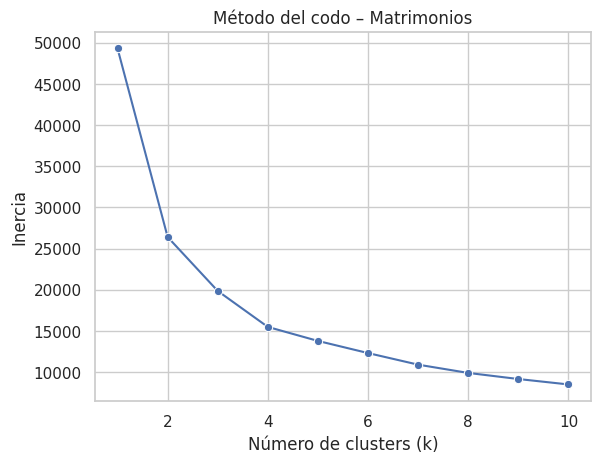

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x=list(krange), y=inercias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo – Matrimonios')
plt.show()


# Task
Apply the K-Means algorithm to the scaled data (`X_scaled`) using the optimal number of clusters (`k_optimo = 3`). Then, visualize the resulting clusters by creating a scatter plot of the first two principal components from `X_pca`, coloring each point according to its assigned cluster label. Finally, summarize the clustering analysis and discuss the main characteristics of the identified clusters based on the visualization.

## Aplicar K-Means

### Subtask:
Aplicar el algoritmo K-Means a los datos escalados (`X_scaled`) utilizando el número óptimo de clusters determinado (`k_optimo = 3`) y obtener las etiquetas de los clusters.


**Reasoning**:
Instantiate and fit the K-Means model to the scaled data and then extract the cluster labels as per the instructions.



In [28]:
kmeans = KMeans(
    n_clusters=6,
    random_state=3,
    n_init=10
)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_
print("K-Means clustering applied and cluster labels obtained.")

K-Means clustering applied and cluster labels obtained.


### Subtask:
Perform Principal Component Analysis (PCA) on the scaled data (`X_scaled`) to reduce its dimensionality to two components, and store the result in `X_pca`.

**Reasoning**:
To prepare the data for visualization, I need to perform Principal Component Analysis (PCA) on the scaled data `X_scaled` to reduce its dimensionality to two components, as specified in the subtask. This involves importing `PCA`, instantiating it with two components, and then fitting and transforming the `X_scaled` data.



In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("PCA performed and X_pca generated.")

PCA performed and X_pca generated.


### Subtask:
Visualize the resulting clusters by creating a scatter plot of the first two principal components from `X_pca`, coloring each point according to its assigned cluster label (`cluster_labels`).

**Reasoning**:
To visualize the clusters, I need to create a scatter plot of the two principal components (`X_pca`), using the `cluster_labels` to differentiate the clusters by color. This step directly addresses the current subtask.



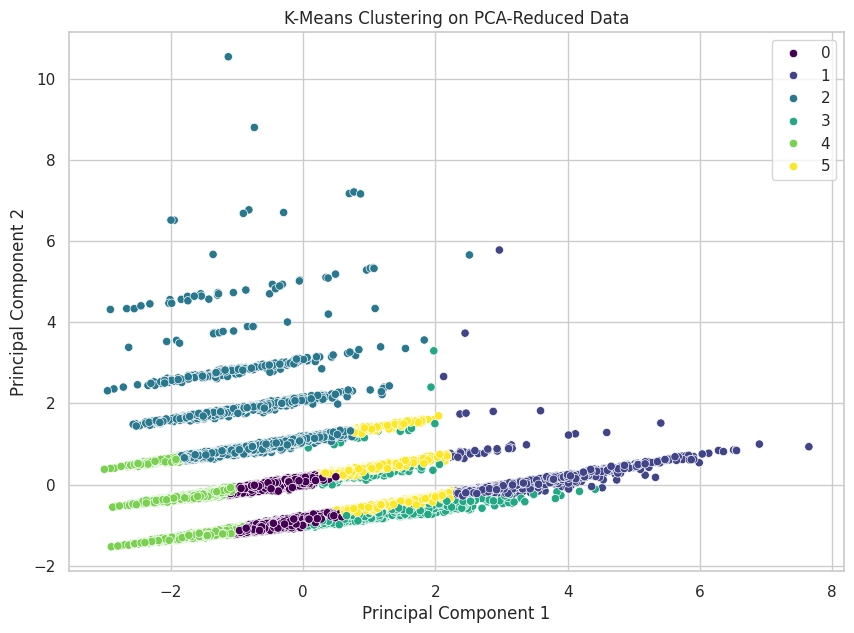

Scatter plot of clusters generated.


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette='viridis',
    legend='full'
)
plt.title('K-Means Clustering on PCA-Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
print("Scatter plot of clusters generated.")

In [31]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Variables de clustering
features = ['edad_1', 'edad_2', 'dur_mat', 'hijos_total']

X = df[features].dropna()
df_cluster = df.loc[X.index].copy()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=3, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)


In [32]:
from itertools import combinations

pairs = list(combinations(features, 2))
pairs


[('edad_1', 'edad_2'),
 ('edad_1', 'dur_mat'),
 ('edad_1', 'hijos_total'),
 ('edad_2', 'dur_mat'),
 ('edad_2', 'hijos_total'),
 ('dur_mat', 'hijos_total')]

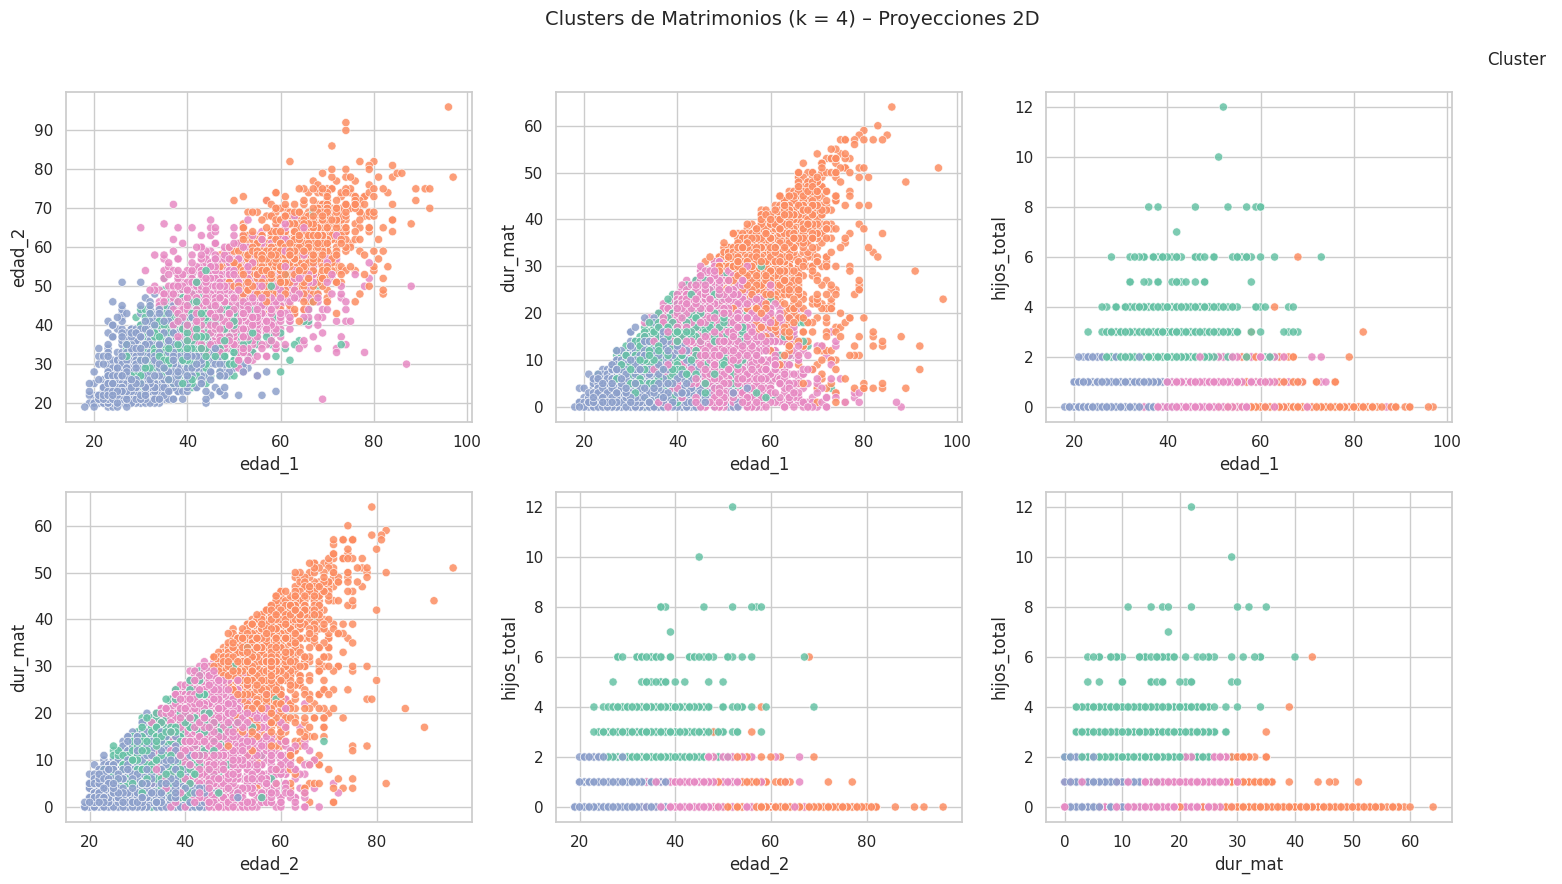

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

n_plots = len(pairs)
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9))
axes = axes.flatten()

for ax, (x_var, y_var) in zip(axes, pairs):
    sns.scatterplot(
        data=df_cluster,
        x=x_var,
        y=y_var,
        hue='cluster',
        palette='Set2',
        s=35,
        alpha=0.85,
        ax=ax,
        legend=False
    )
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)

# Leyenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Cluster",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.95),
    frameon=False
)

plt.suptitle("Clusters de Matrimonios (k = 4) – Proyecciones 2D", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()


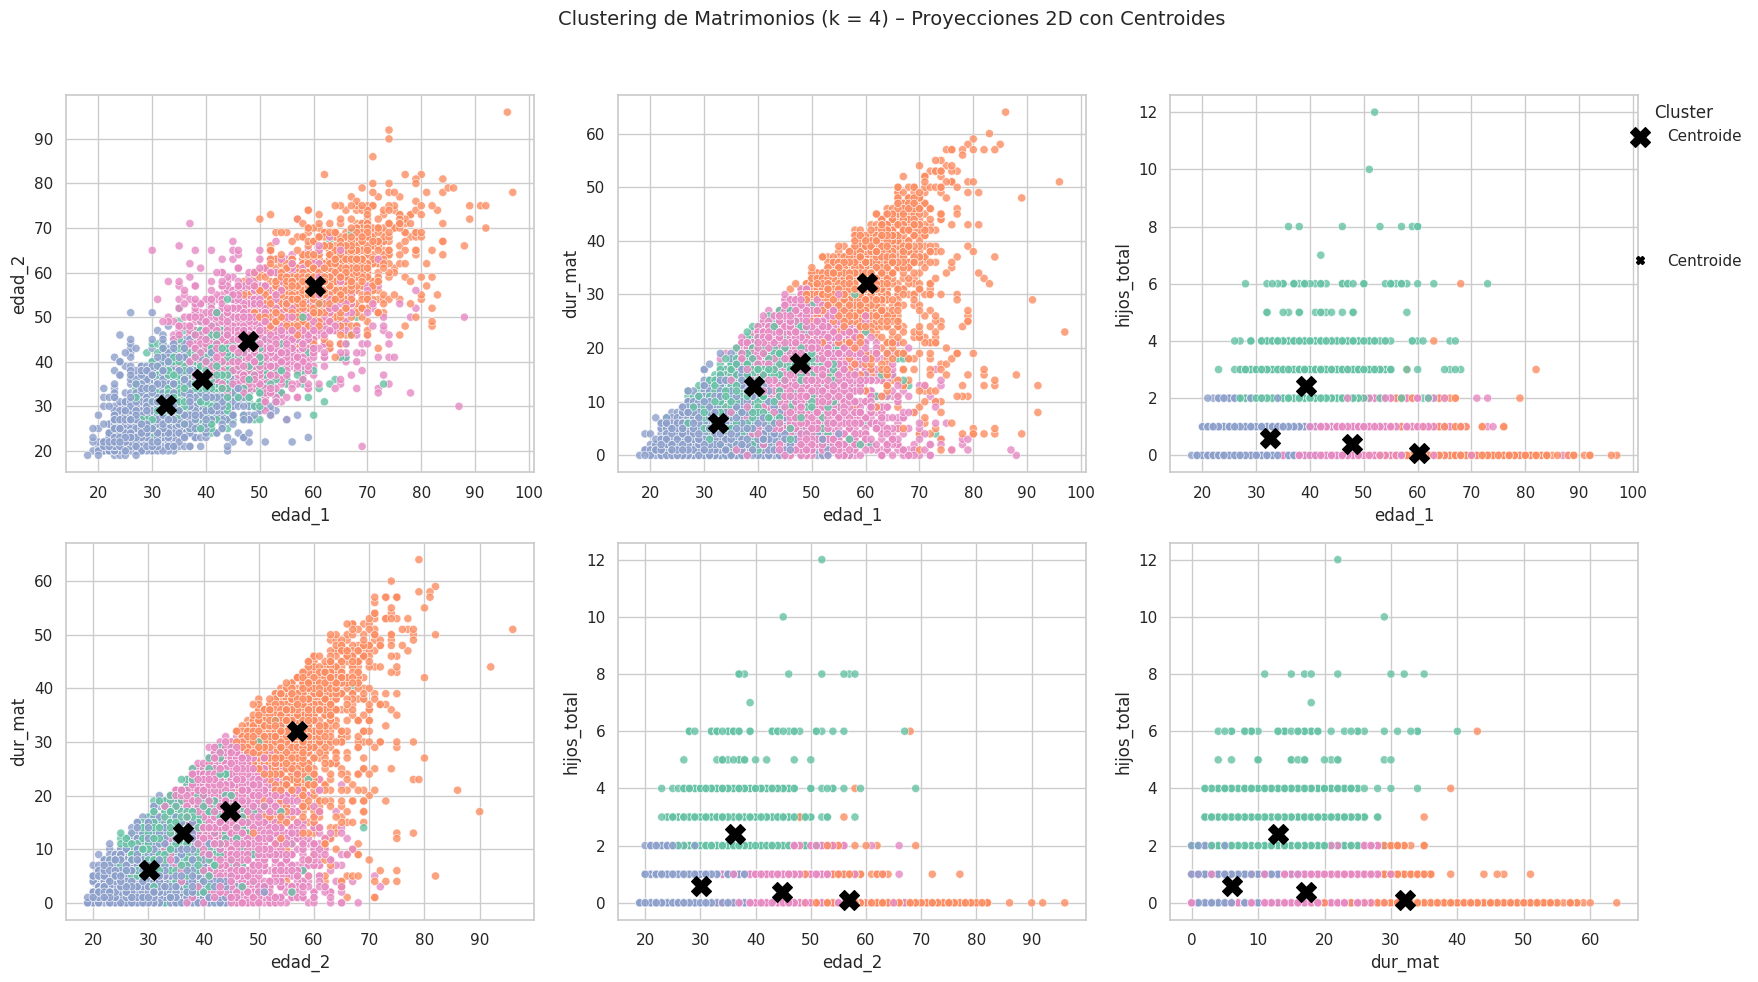

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Selección de variables
# =========================
features = ['edad_1', 'edad_2', 'dur_mat', 'hijos_total']

X = df[features].dropna()
df_cluster = df.loc[X.index].copy()

# =========================
# 2. Escalado
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 3. Pedir número de clusters
# =========================
k = int(input("Ingrese el número de clusters (k): "))

# =========================
# 4. KMeans
# =========================
kmeans = KMeans(
    n_clusters=k,
    random_state=3,
    n_init=10
)

df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# =========================
# 5. Centroides (escala original)
# =========================
centroides_scaled = kmeans.cluster_centers_
centroides = scaler.inverse_transform(centroides_scaled)
df_centroides = pd.DataFrame(centroides, columns=features)

# =========================
# 6. Combinaciones 2D
# =========================
pairs = list(combinations(features, 2))

# =========================
# 7. Gráficos
# =========================
sns.set_theme(style="whitegrid")

n_plots = len(pairs)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for ax, (x_var, y_var) in zip(axes, pairs):

    # Scatter de datos
    sns.scatterplot(
        data=df_cluster,
        x=x_var,
        y=y_var,
        hue='cluster',
        palette='Set2',
        s=35,
        alpha=0.8,
        ax=ax,
        legend=False
    )

    # Scatter de centroides
    ax.scatter(
        df_centroides[x_var],
        df_centroides[y_var],
        c='black',
        s=200,
        marker='X',
        label='Centroide'
    )

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)

# Eliminar ejes vacíos si sobran
for i in range(len(pairs), len(axes)):
    fig.delaxes(axes[i])

# =========================
# 8. Leyenda única
# =========================
handles_clusters, labels_clusters = axes[0].get_legend_handles_labels()

fig.legend(
    handles_clusters,
    labels_clusters,
    title="Cluster",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.9),
    frameon=False
)

fig.legend(
    [plt.Line2D([0], [0], marker='X', color='black', linestyle='')],
    ['Centroide'],
    loc="upper right",
    bbox_to_anchor=(0.98, 0.75),
    frameon=False
)

plt.suptitle(
    f"Clustering de Matrimonios (k = {k}) – Proyecciones 2D con Centroides",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()


In [35]:
# =========================
# Nuevos features
# =========================
df['hijos_total'] = df[['hijos_1', 'hijos_2']].sum(axis=1)

df['nivel_pareja'] = df[['niv_inst1', 'niv_inst2']].mean(axis=1)


In [36]:
features = [
    'edad_1',
    'edad_2',
    'dur_mat',
    'hijos_total',
    'nivel_pareja'
]


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Subset y eliminación de NA solo en features usadas
X = df[features].dropna()
df_cluster = df.loc[X.index].copy()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Pedir número de clusters
k = int(input("Ingrese el número de clusters (k): "))

# KMeans
kmeans = KMeans(
    n_clusters=k,
    random_state=3,
    n_init=10
)

df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Centroides en escala original
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
df_centroides = pd.DataFrame(centroides, columns=features)


In [38]:
pairs_plot = [
    ('dur_mat', 'hijos_total'),
    ('dur_mat', 'nivel_pareja'),
    ('hijos_total', 'nivel_pareja')
]


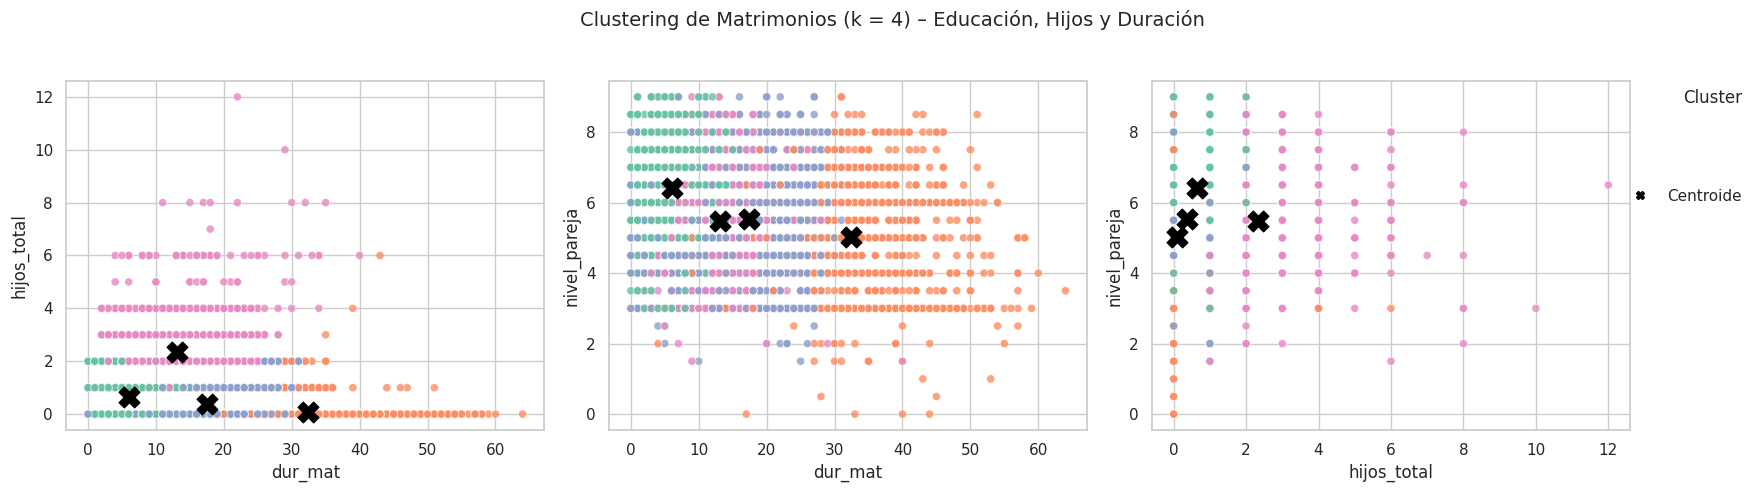

In [39]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x_var, y_var) in zip(axes, pairs_plot):

    # Datos
    sns.scatterplot(
        data=df_cluster,
        x=x_var,
        y=y_var,
        hue='cluster',
        palette='Set2',
        s=35,
        alpha=0.8,
        ax=ax,
        legend=False
    )

    # Centroides
    ax.scatter(
        df_centroides[x_var],
        df_centroides[y_var],
        c='black',
        s=220,
        marker='X'
    )

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)

# Leyenda única
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Cluster",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.85),
    frameon=False
)

fig.legend(
    [plt.Line2D([0], [0], marker='X', color='black', linestyle='')],
    ['Centroide'],
    loc="upper right",
    bbox_to_anchor=(0.98, 0.65),
    frameon=False
)

plt.suptitle(
    f"Clustering de Matrimonios (k = {k}) – Educación, Hijos y Duración",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.show()


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [41]:
# Total de hijos
df['hijos_total'] = df[['hijos_1', 'hijos_2']].sum(axis=1)

# Diferencia de nivel de instrucción (mayor - menor)
df['dif_nivel_inst'] = (
    df[['niv_inst1', 'niv_inst2']]
    .max(axis=1) - df[['niv_inst1', 'niv_inst2']].min(axis=1)
)


In [42]:
features = [
    'edad_1',
    'edad_2',
    'dur_mat',
    'hijos_total',
    'niv_inst1',
    'niv_inst2',
    'dif_nivel_inst'
]


In [43]:
X = df[features].dropna()
df_cluster = df.loc[X.index].copy()


In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [45]:
k = int(input("Ingrese el número de clusters (k): "))


In [46]:
kmeans = KMeans(
    n_clusters=k,
    random_state=3,
    n_init=10
)

df_cluster['cluster'] = kmeans.fit_predict(X_scaled)


In [47]:
centroides_scaled = kmeans.cluster_centers_
centroides = scaler.inverse_transform(centroides_scaled)

df_centroides = pd.DataFrame(centroides, columns=features)


In [48]:
vars_interes = [
    'edad_1',
    'edad_2',
    'niv_inst1',
    'niv_inst2',
    'dif_nivel_inst'
]

pairs = []

for var in vars_interes:
    pairs.append((var, 'dur_mat'))
    pairs.append((var, 'hijos_total'))


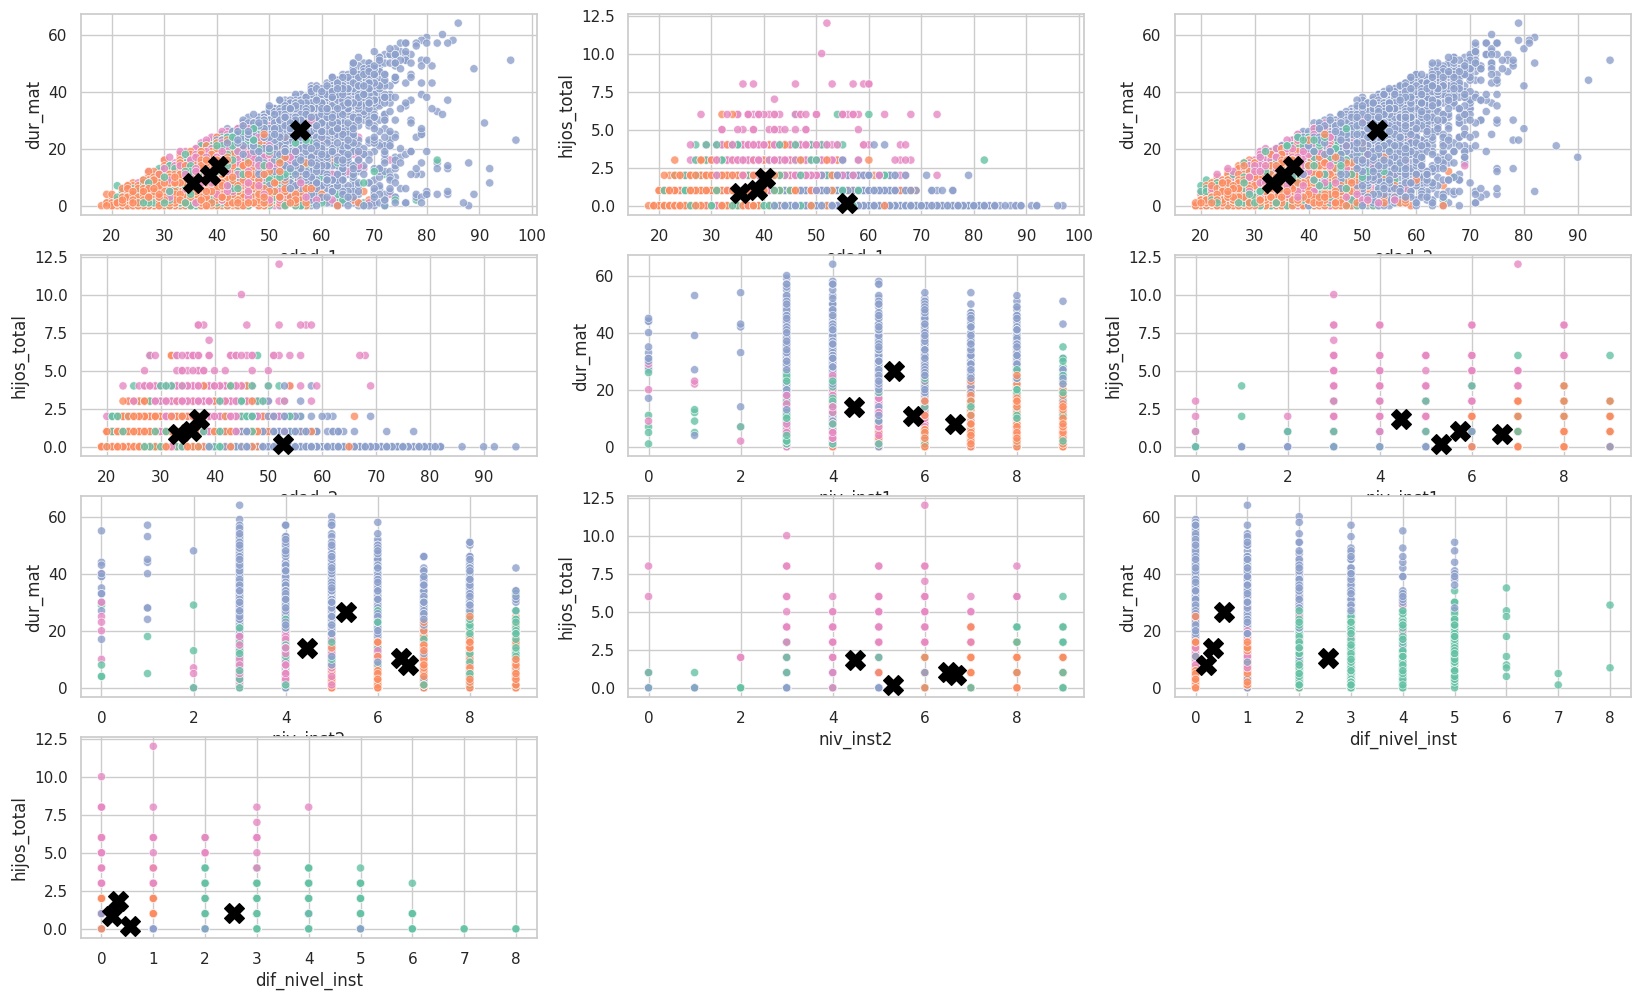

In [49]:
sns.set_theme(style="whitegrid")

n_plots = len(pairs)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

for ax, (x_var, y_var) in zip(axes, pairs):

    # Datos
    sns.scatterplot(
        data=df_cluster,
        x=x_var,
        y=y_var,
        hue='cluster',
        palette='Set2',
        s=35,
        alpha=0.8,
        ax=ax,
        legend=False
    )

    # Centroides
    ax.scatter(
        df_centroides[x_var],
        df_centroides[y_var],
        c='black',
        s=200,
        marker='X'
    )

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)

# Eliminar ejes vacíos
for i in range(len(pairs), len(axes)):
    fig.delaxes(axes[i])


In [50]:
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Cluster",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.9),
    frameon=False
)

fig.legend(
    [plt.Line2D([0], [0], marker='X', color='black', linestyle='')],
    ['Centroide'],
    loc="upper right",
    bbox_to_anchor=(0.98, 0.75),
    frameon=False
)

plt.suptitle(
    f"Clustering de Matrimonios (k = {k})\nDuración del Matrimonio y Número de Hijos",
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 0.93, 0.94])
plt.show()


<Figure size 640x480 with 0 Axes>

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [52]:
# Edad promedio de la pareja
df['edad_prom'] = (df['edad_1'] + df['edad_2']) / 2

# Diferencia de nivel institucional (mayor - menor)
df['dif_nivel_inst'] = (
    df[['niv_inst1', 'niv_inst2']]
    .max(axis=1) - df[['niv_inst1', 'niv_inst2']].min(axis=1)
)


In [53]:
features = ['edad_prom', 'dif_nivel_inst']

X = df[features].dropna()
df_cluster = df.loc[X.index].copy()


In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [55]:
k = int(input("Ingrese el número de clusters (k): "))


In [56]:
kmeans = KMeans(
    n_clusters=k,
    random_state=3,
    n_init=10
)

df_cluster['cluster'] = kmeans.fit_predict(X_scaled)


In [57]:
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
df_centroides = pd.DataFrame(centroides, columns=features)


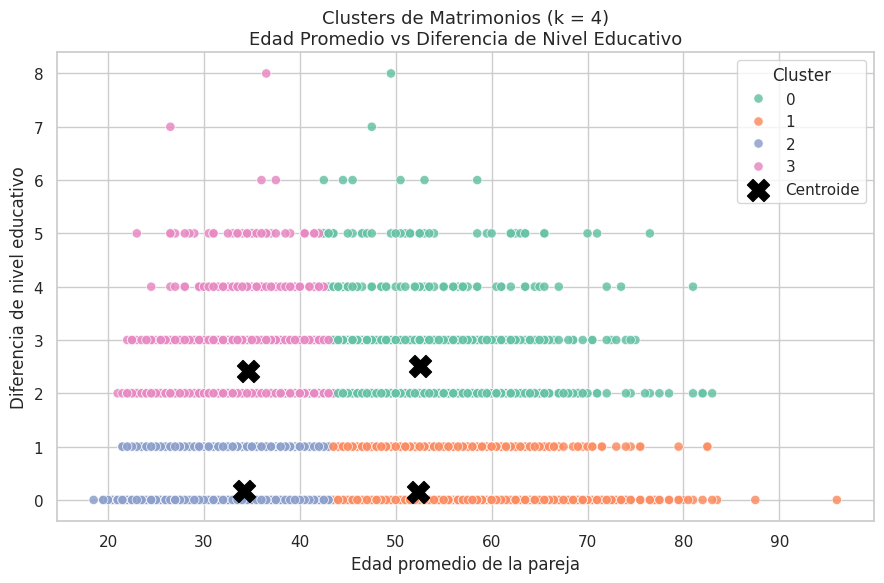

In [58]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 6))

# Datos
sns.scatterplot(
    data=df_cluster,
    x='edad_prom',
    y='dif_nivel_inst',
    hue='cluster',
    palette='Set2',
    s=45,
    alpha=0.85
)

# Centroides
plt.scatter(
    df_centroides['edad_prom'],
    df_centroides['dif_nivel_inst'],
    c='black',
    s=250,
    marker='X',
    label='Centroide'
)

plt.title(
    f"Clusters de Matrimonios (k = {k})\nEdad Promedio vs Diferencia de Nivel Educativo",
    fontsize=13
)

plt.xlabel("Edad promedio de la pareja")
plt.ylabel("Diferencia de nivel educativo")

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()
